# State-Space Bayesian Operator Inference: Compressible Euler

**Model B** — dynamics generate states directly. No GP, no derivative conditioning.
The operator O is identified by the temporal evolution of the data through an
Euler-discretised state-space model.

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import jax
import jax.numpy as jnp
import opinf
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive, autoguide
from jax import random

from core import generate_trajectory, JaxCompatibleModel
import importlib
sys.path.insert(0, '../euler')
import config
from config import Basis

numpyro.set_platform('cpu')
np.random.seed(42)
rng_key = random.PRNGKey(42)

In [2]:
# === EXPERIMENT CONFIGURATION ===
OPERATORS = "cAH"
IVP_METHOD = "RK45"
NUM_MODES = 6

# Data generation
TRAINING_SPAN = (0, 0.08)
PREDICTION_SPAN = (0, config.time_domain[-1])
NUM_SAMPLES = 250
NOISE_LEVEL = 0.03

# Model B hyperparameters
GAMMA = 10.0           # operator prior scale
NUM_SVI_STEPS = 20000
LEARNING_RATE = 1e-3
NUM_POSTERIOR_SAMPLES = 500

In [3]:
# Generate training data (same pattern as notebook 03)
(fom, time_domain_full, true_states, time_sampled, snapshots_sampled) =     generate_trajectory(config, config.time_domain, TRAINING_SPAN, NUM_SAMPLES, NOISE_LEVEL)

print(f"Full time domain: {time_domain_full.shape}")
print(f"True states: {true_states.shape}")
print(f"Sampled times: {time_sampled.shape}")
print(f"Training span: [{TRAINING_SPAN[0]:.4f}, {TRAINING_SPAN[1]:.4f}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]:.4f}, {PREDICTION_SPAN[1]:.4f}]")

# Fit POD basis and compress
basis = Basis(num_vectors=NUM_MODES)
basis.fit(snapshots_sampled)

snapshots_comp_sampled = basis.compress(snapshots_sampled)
full_states_compressed = basis.compress(true_states)

print(f"Compressed shape: {snapshots_comp_sampled.shape}")
print(f"Cumulative energy: {basis.cumulative_energy:.4%}")

generating training data...done in 0.93 s.
Full time domain: (401,)
True states: (600, 401)
Sampled times: (250,)
Training span: [0.0000, 0.0800]
Prediction span: [0.0000, 0.1500]
Compressed shape: (6, 250)
Cumulative energy: 88.2756%


In [4]:
# Build ROM object for data matrix assembly (operator structure)
rom = opinf.ROM(
    basis=basis,
    ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_sampled),
    model=JaxCompatibleModel(
        operators=OPERATORS,
        solver=opinf.lstsq.L2Solver(regularizer=1e0),
    ),
)
rom.fit(states=snapshots_sampled)

r = NUM_MODES
d = rom.model.operator_matrix.shape[1]
print(f"Operator matrix shape: ({r}, {d})")

# Verify data matrix assembly shapes
x_test = jnp.array(snapshots_comp_sampled[:, 0:1])  # (r, 1)
f_test = rom.model._assemble_data_matrix(x_test, inputs=None)
print(f"f(x) shape for single state (r,1) input: {f_test.shape}  [expect (1, {d})]")

Operator matrix shape: (6, 28)
f(x) shape for single state (r,1) input: (1, 28)  [expect (1, 28)]


In [5]:
def state_space_model(y_obs, dt, rom_model, gamma=10.0):
    """State-space Bayesian operator inference (Model B).

    Deterministic dynamics: X is a function of O only.
    No latent state variables — the operator alone determines the trajectory.
    """
    r, K = y_obs.shape
    d = rom_model.operator_matrix.shape[1]

    # --- Priors ---
    O = numpyro.sample("O", dist.Normal(jnp.zeros((r, d)), gamma))
    log_R = numpyro.sample("log_R", dist.Normal(jnp.log(NOISE_LEVEL), 0.5))
    R = jnp.exp(log_R)

    # --- Deterministic forward integration ---
    X_prev = y_obs[:, 0]
    numpyro.sample("obs_0", dist.Normal(X_prev, jnp.sqrt(R)), obs=y_obs[:, 0])

    for k in range(K - 1):
        f_X = rom_model._assemble_data_matrix(
            X_prev.reshape(-1, 1), inputs=None
        )
        X_prev = X_prev + dt[k] * (f_X @ O.T).squeeze()
        numpyro.deterministic(f"X_{k + 1}", X_prev)
        numpyro.sample(
            f"obs_{k + 1}",
            dist.Normal(X_prev, jnp.sqrt(R)),
            obs=y_obs[:, k + 1],
        )


In [ ]:
# Compute time steps between observations
dt = jnp.diff(jnp.array(time_sampled))

guide = autoguide.AutoNormal(state_space_model)
optimizer = numpyro.optim.Adam(step_size=LEARNING_RATE)
svi = SVI(state_space_model, guide, optimizer, loss=Trace_ELBO())

svi_result = svi.run(
    rng_key,
    NUM_SVI_STEPS,
    y_obs=jnp.array(snapshots_comp_sampled),
    dt=dt,
    rom_model=rom.model,
    gamma=GAMMA,
    progress_bar=True,
)

# Plot ELBO convergence
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(svi_result.losses)
ax.set_xlabel("Iteration")
ax.set_ylabel("ELBO Loss")
ax.set_title("Model B: SVI Convergence")
plt.tight_layout()
plt.show()

  0%|          | 0/20000 [00:00<?, ?it/s]

In [ ]:
params = svi_result.params
rng_key, sample_key, pred_key = random.split(rng_key, 3)

# Sample latent variables from the learned guide
posterior_samples = guide.sample_posterior(
    sample_key, params, sample_shape=(NUM_POSTERIOR_SAMPLES,)
)

# Run predictive to get deterministic sites
predictive = Predictive(
    state_space_model,
    posterior_samples=posterior_samples,
    num_samples=NUM_POSTERIOR_SAMPLES,
)
model_output = predictive(
    pred_key,
    y_obs=jnp.array(snapshots_comp_sampled),
    dt=dt,
    rom_model=rom.model,
    gamma=GAMMA,
)

# Merge guide samples + model output
samples = {**model_output, **posterior_samples}

# Operator summary statistics
O_samples = samples['O']
print(f"Operator samples shape: {O_samples.shape}")
print(f"Operator norm (median): {np.median(np.linalg.norm(O_samples, axis=(1, 2))):.4f}")
print(f"Process noise Q (median): {np.median(np.exp(np.array(samples['log_Q']))):.6f}")
print(f"Obs noise R (median): {np.median(np.exp(np.array(samples['log_R']))):.6f}")

Operator samples shape: (500, 6, 28)
Operator norm (median): 128.5315
Process noise Q (median): 0.002230
Obs noise R (median): 0.000255


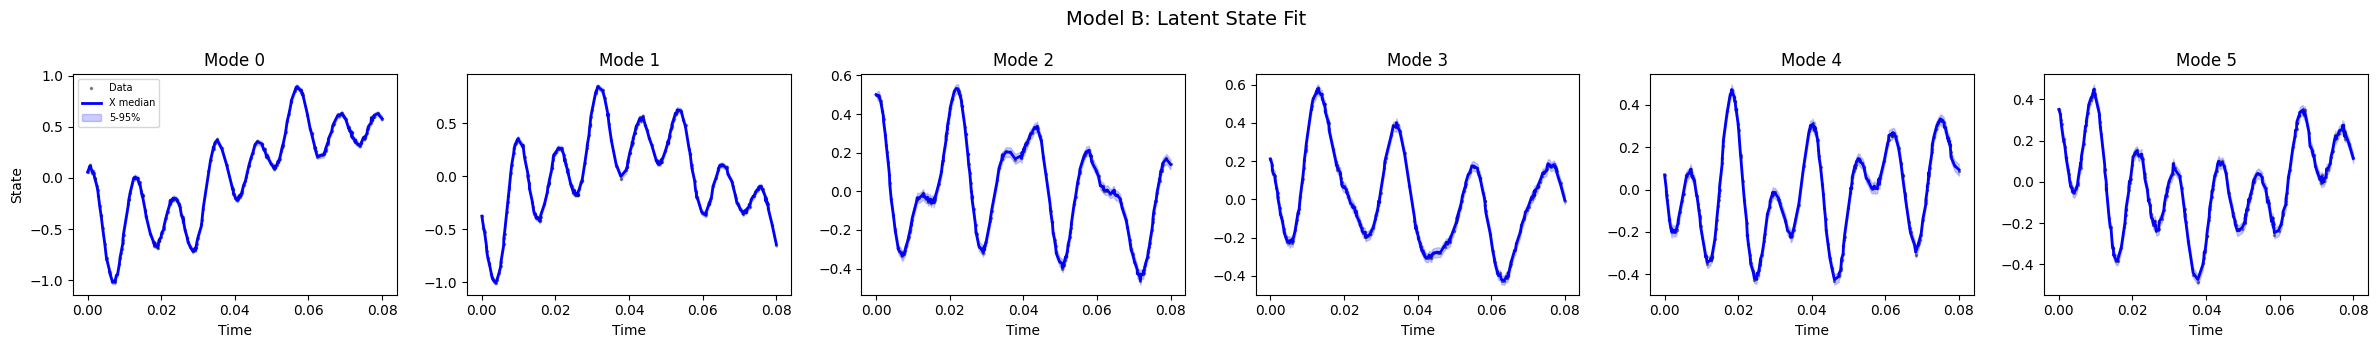

In [ ]:
fig, axes = plt.subplots(1, NUM_MODES, figsize=(4 * NUM_MODES, 3.5), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.plot(time_sampled, snapshots_comp_sampled[i], "k.", ms=3, alpha=0.4, label="Data")

    # Collect deterministic X samples for mode i
    X_mode = np.zeros((NUM_POSTERIOR_SAMPLES, NUM_SAMPLES))
    X_mode[:, 0] = snapshots_comp_sampled[i, 0]
    for k in range(1, NUM_SAMPLES):
        if f"X_{k}" in samples:
            X_mode[:, k] = np.array(samples[f"X_{k}"][:, i])
        else:
            X_mode[:, k] = X_mode[:, 0]  # fallback

    median = np.median(X_mode, axis=0)
    q05 = np.percentile(X_mode, 5, axis=0)
    q95 = np.percentile(X_mode, 95, axis=0)

    ax.plot(time_sampled, median, "b-", lw=2, label="X median")
    ax.fill_between(time_sampled, q05, q95, alpha=0.2, color="blue", label="5-95%")
    ax.set_title(f"Mode {i}")
    if i == 0:
        ax.set_ylabel("State")
        ax.legend(fontsize=7)
    ax.set_xlabel("Time")

fig.suptitle("Model B: Latent State Fit (Deterministic Dynamics)", fontsize=14)
plt.tight_layout()
plt.show()


Stable ROM solves: 48/200


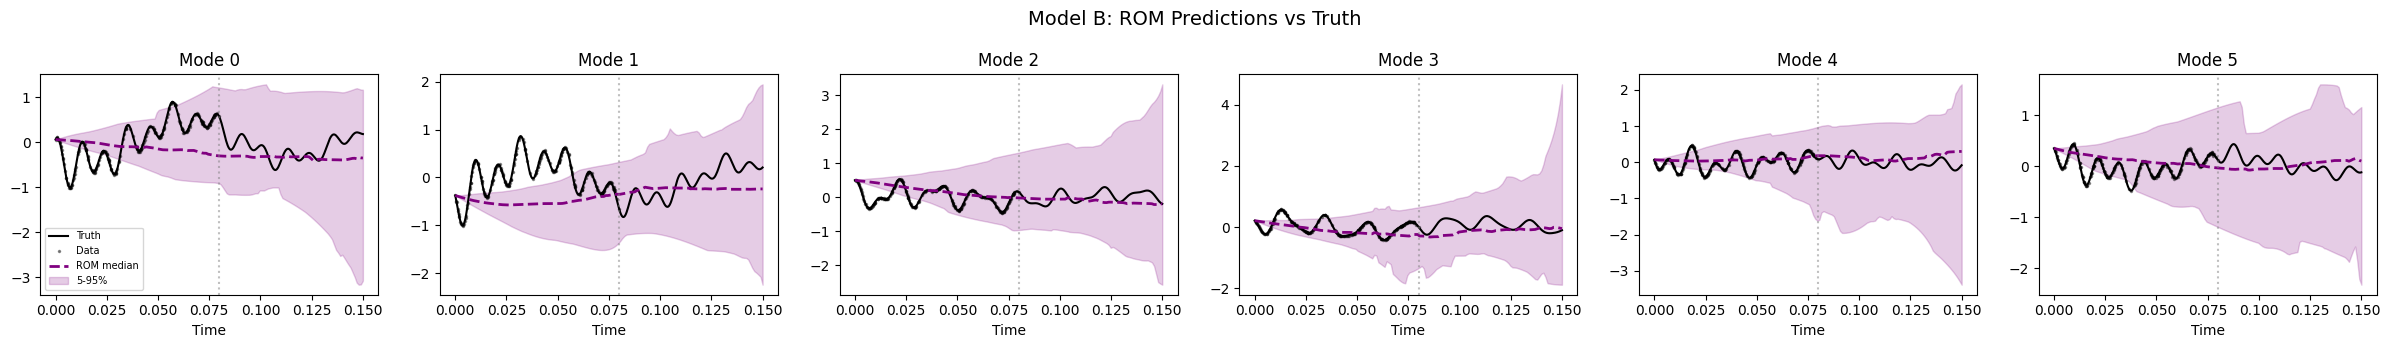

In [ ]:
# Evaluate ROM predictions using posterior operator samples
NUM_REGRESSION_POINTS = 150
time_domain_eval = np.linspace(PREDICTION_SPAN[0], PREDICTION_SPAN[1], NUM_REGRESSION_POINTS)

stable_count = 0
rom_solves = []

for s in range(min(200, NUM_POSTERIOR_SAMPLES)):
    O_s = np.array(O_samples[s])
    rom.model._extract_operators(O_s)
    try:
        sol = rom.model.predict(
            state0=np.array(snapshots_comp_sampled[:, 0]),
            t=time_domain_eval,
            method=IVP_METHOD,
        )
        if rom.model.predict_result_.y.shape[1] >= len(time_domain_eval):
            rom_solves.append(rom.model.predict_result_.y)
            stable_count += 1
    except Exception:
        pass

print(f"Stable ROM solves: {stable_count}/{min(200, NUM_POSTERIOR_SAMPLES)}")

# Plot ROM predictions vs truth
fig, axes = plt.subplots(1, NUM_MODES, figsize=(4 * NUM_MODES, 3.5), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.plot(time_domain_full, full_states_compressed[i], "k-", lw=1.5, label="Truth")
    ax.plot(time_sampled, snapshots_comp_sampled[i], "k.", ms=3, alpha=0.4, label="Data")

    if rom_solves:
        rom_arr = np.array(rom_solves)
        med = np.median(rom_arr[:, i, :], axis=0)
        q05 = np.percentile(rom_arr[:, i, :], 5, axis=0)
        q95 = np.percentile(rom_arr[:, i, :], 95, axis=0)
        ax.plot(time_domain_eval, med, "purple", ls="--", lw=2, label="ROM median")
        ax.fill_between(time_domain_eval, q05, q95, alpha=0.2, color="purple", label="5-95%")

    ax.axvline(TRAINING_SPAN[1], color="gray", ls=":", alpha=0.5)
    ax.set_title(f"Mode {i}")
    if i == 0:
        ax.legend(fontsize=7)
    ax.set_xlabel("Time")

fig.suptitle("Model B: ROM Predictions vs Truth", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# === Experiment Summary ===
print("=" * 60)
print("Model B — State-Space Bayesian Operator Inference")
print("=" * 60)
print(f"PDE: Compressible Euler equations")
print(f"Operator structure: {OPERATORS}")
print(f"POD modes: {NUM_MODES}")
print(f"Training span: {TRAINING_SPAN}")
print(f"Num observations: {NUM_SAMPLES}")
print(f"Noise level: {NOISE_LEVEL:.0%}")
print(f"Operator prior scale (gamma): {GAMMA}")
print(f"SVI steps: {NUM_SVI_STEPS}")
print(f"Posterior samples: {NUM_POSTERIOR_SAMPLES}")
print(f"Stable ROM solves: {stable_count}/{min(200, NUM_POSTERIOR_SAMPLES)}")
if rom_solves:
    O_med = np.median(np.array(O_samples), axis=0)
    print(f"Median operator Frobenius norm: {np.linalg.norm(O_med):.4f}")
    print(f"Process noise Q (median): {np.median(np.exp(np.array(samples["log_Q"]))):.6f}")
    print(f"Obs noise R (median): {np.median(np.exp(np.array(samples["log_R"]))):.6f}")
print("=" * 60)

Model B — State-Space Bayesian Operator Inference
PDE: Compressible Euler equations
Operator structure: cAH
POD modes: 6
Training span: (0, 0.08)
Num observations: 250
Noise level: 3%
Operator prior scale (gamma): 10.0
SVI steps: 20000
Posterior samples: 500
Stable ROM solves: 48/200
Median operator Frobenius norm: 57.7008
Process noise Q (median): 0.002230
Obs noise R (median): 0.000255
